In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Check available sheet names first
xls = pd.ExcelFile('../data/online_retail_II.xlsx')
print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [4]:
# Load each sheet into its own DataFrame
df_2009_2010 = pd.read_excel(xls, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(xls, sheet_name='Year 2010-2011')

In [5]:
df_2009_2010["SourceSheet"] = "2009-2010"
df_2010_2011["SourceSheet"] = "2010-2011"

In [6]:
# Combine into one DataFrame
df_all = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
df = df_all.copy()

In [7]:
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010


In [8]:
df.isna().sum() 

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
SourceSheet         0
dtype: int64

In [9]:
# Let's check how big dataset is.
# .shape gives us (number of rows, number of columns).
print("The dataset has:", df.shape[0], "rows and", df.shape[1], "columns")

The dataset has: 1067371 rows and 9 columns


In [10]:

# List the column names so we know exactly what we have.
print("\nColumns:", list(df.columns))


Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SourceSheet']


In [11]:
# Information in dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   SourceSheet  1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 73.3+ MB


## Data Cleaning

### 1. Fix data types

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Invoice'] = df['Invoice'].astype(str).str.strip()
df['StockCode'] = df['StockCode'].astype(str).str.strip().str.upper()
df['Description'] = df['Description'].astype(str).str.strip()
df['Country'] = df['Country'].astype(str).str.strip()

### 2. Remove exact duplicate rows

In [13]:
# Show the duplicated rows (all occurrences, not just the extra copies)
duplicate_rows = df[df.duplicated(subset=list(df.columns), keep=False)]
print(f"Found {len(duplicate_rows)} rows involved in duplication")
duplicate_rows.sort_values(by=list(df.columns)).head(10)

Found 23430 rows involved in duplication


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,2009-2010


In [14]:
# 2. Remove exact duplicate rows
before = len(df)
df_clean = df.drop_duplicates(list(df.columns))
print(f"Dropped {before - len(df_clean)} exact duplicate rows -> {len(df_clean)} left")

Dropped 12133 exact duplicate rows -> 1055238 left


### 3. Drop rows with missing Customer ID

In [15]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
print(f"Dropped {before - len(df_clean)} rows with missing Customer ID -> {len(df_clean)} left")

Dropped 242870 rows with missing Customer ID -> 812368 left


### 4. Drop rows with missing Description

In [16]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Dropped {before - len(df_clean)} rows with missing Description -> {len(df_clean)} left")

Dropped 0 rows with missing Description -> 812368 left


### 5. Remove non-product / administrative stock codes

In [17]:
# -----------------------------------------------------------------------
# 5. Remove non-product / administrative stock codes
# -----------------------------------------------------------------------
# These codes are postage, fees, manual adjustments, bank charges, samples,
# discounts and test entries — not real products, so they'd distort RFM,
# segmentation and product-level analysis.
admin_codes = [
    'POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES',
    'ADJUST', 'ADJUST2', 'AMAZONFEE', 'CRUK', 'TEST001', 'TEST002', 'B'
]
before = len(df_clean)
df_clean = df_clean[~df_clean['StockCode'].isin(admin_codes)]
print(f"Dropped {before - len(df_clean)} rows with admin/non-product stock codes -> {len(df_clean)} left")


Dropped 3706 rows with admin/non-product stock codes -> 808662 left


### 6. Separate cancellations (returns) from the sales dataset

Invoices starting with 'C' are cancellations. Keep them in a separate  dataframe in case you want to analyze returns later,
but exclude them  from the "sales" dataset used for RFM/segmentation/prediction.

In [18]:
is_cancelled = df_clean['Invoice'].str.startswith('C')
df_returns = df_clean[is_cancelled].copy()
df_clean = df_clean[~is_cancelled].copy()
print(f"Separated {len(df_returns)} cancelled-order rows into df_returns -> {len(df_clean)} sales rows left")

Separated 17879 cancelled-order rows into df_returns -> 790783 sales rows left


### 7. Remove non-positive quantities and prices
A handful of negative-quantity rows aren't flagged as cancellations , and  zero/negative prices are data errors 
or free/adjustment items with no real revenue signal.

In [19]:
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {before - len(df_clean)} rows with Quantity <= 0 or Price <= 0 -> {len(df_clean)} left")

Dropped 62 rows with Quantity <= 0 or Price <= 0 -> 790721 left


In [20]:
# -----------------------------------------------------------------------
# 8. Remove extreme price outliers (optional sanity cap)
# -----------------------------------------------------------------------
# A few Price values are in the thousands and clearly not per-unit retail  prices.
#Flag anything beyond the 99.9th percentile for review instead of  silently dropping, so you can decide case by case.
#price_cap = df_clean['Price'].quantile(0.999)
#n_outliers = (df_clean['Price'] > price_cap).sum()
#print(f"{n_outliers} rows have Price above the 99.9th percentile ({price_cap:.2f}) — inspect before deciding to cap/drop")

### 9. Add the Revenue column (needed for EDA/RFM downstream)

In [21]:
df_clean= df_clean.drop(columns=['SourceSheet'])

In [22]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


### Final Data cleaning Summary

In [23]:
df_clean = df_clean.reset_index(drop=True)
print("\n==== CLEANING SUMMARY ====")
print(f"Raw rows:        {len(df):,}")
print(f"Clean sales rows:{len(df_clean):,}")
print(f"Returns rows:    {len(df_returns):,}")
print(f"Remaining missing values:\n{df_clean.isna().sum()}")


==== CLEANING SUMMARY ====
Raw rows:        1,067,371
Clean sales rows:790,721
Returns rows:    17,879
Remaining missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


## Exploratory Data Analysis (EDA)

### Overview of cleaned dataset

In [24]:
print("=== 1. OVERVIEW ===")
print(f"Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}")
print(f"Date range: {df_clean['InvoiceDate'].min()} -> {df_clean['InvoiceDate'].max()}")
print("Time span:", df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min())
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Unique invoices: {df_clean['Invoice'].nunique():,}")
print(f"Unique products (StockCode): {df_clean['StockCode'].nunique():,}")
print(f"Unique countries: {df_clean['Country'].nunique()}")

=== 1. OVERVIEW ===
Rows: 790,721 | Columns: 9
Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Time span: 738 days 05:05:00
Unique customers: 5,852
Unique invoices: 36,594
Unique products (StockCode): 4,621
Unique countries: 41


### 2. Descriptive statistics


=== 2. DESCRIPTIVE STATISTICS ===
            Quantity          Price        Revenue
count  790721.000000  790721.000000  790721.000000
mean       13.476514       2.936808      21.976000
std       144.931071       4.297986     224.229264
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      11.900000
75%        12.000000       3.750000      19.800000
max     80995.000000     649.500000  168469.600000


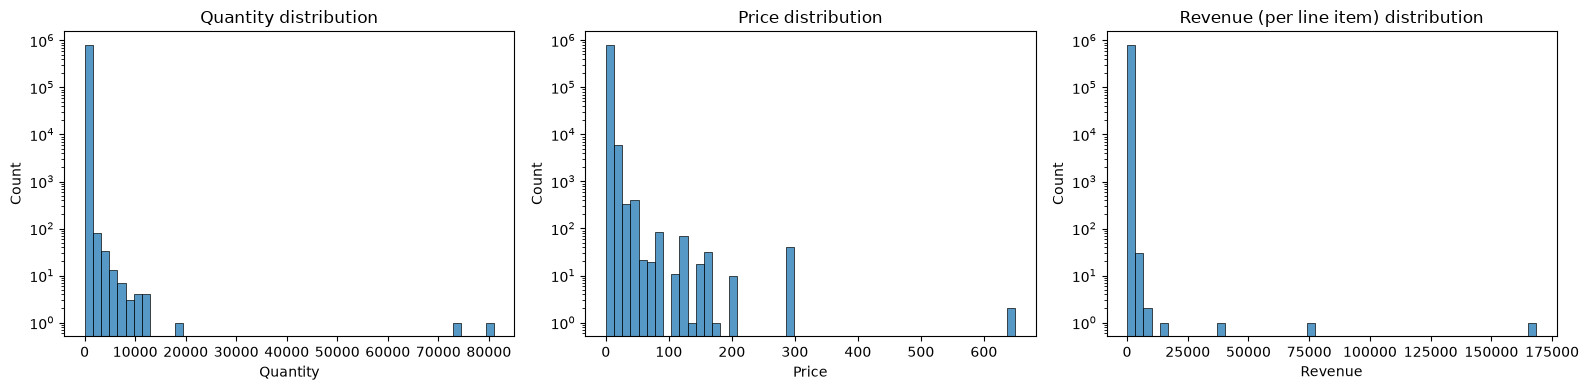

In [25]:
print("\n=== 2. DESCRIPTIVE STATISTICS ===")
print(df_clean[['Quantity', 'Price', 'Revenue']].describe())
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Quantity distribution')
axes[0].set_yscale('log')
 
sns.histplot(df_clean['Price'], bins=50, ax=axes[1])
axes[1].set_title('Price distribution')
axes[1].set_yscale('log')
 
sns.histplot(df_clean['Revenue'], bins=50, ax=axes[2])
axes[2].set_title('Revenue (per line item) distribution')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### 3. Revenue over time


======================= 3. MONTHLY REVENUE TREND =========================


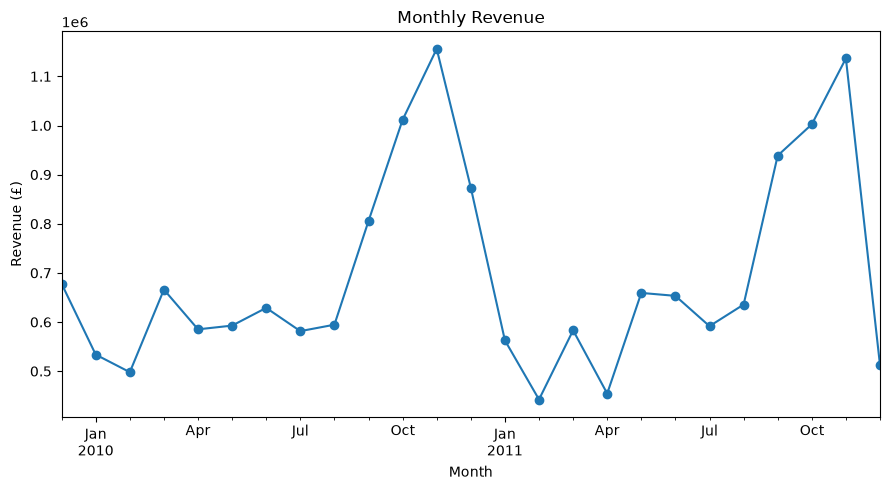

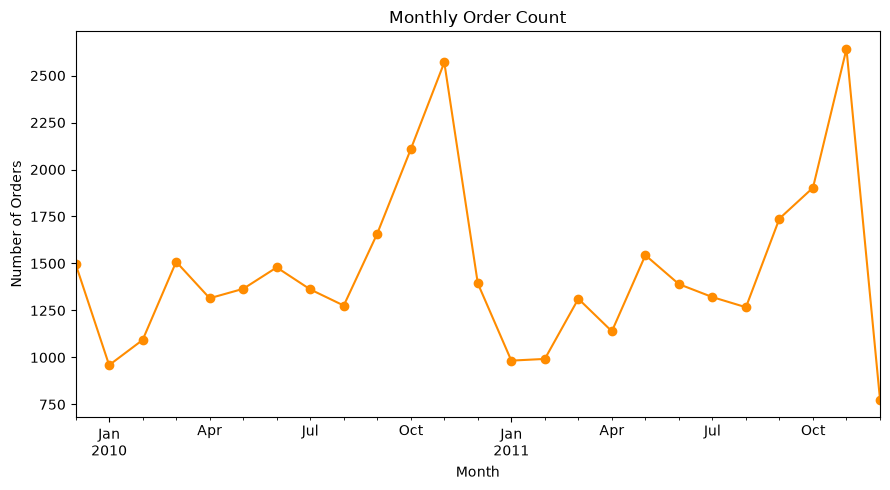

In [26]:
print("\n======================= 3. MONTHLY REVENUE TREND =========================")
monthly_revenue = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
 
monthly_orders = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Invoice']
    .nunique()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_orders.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Order Count')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


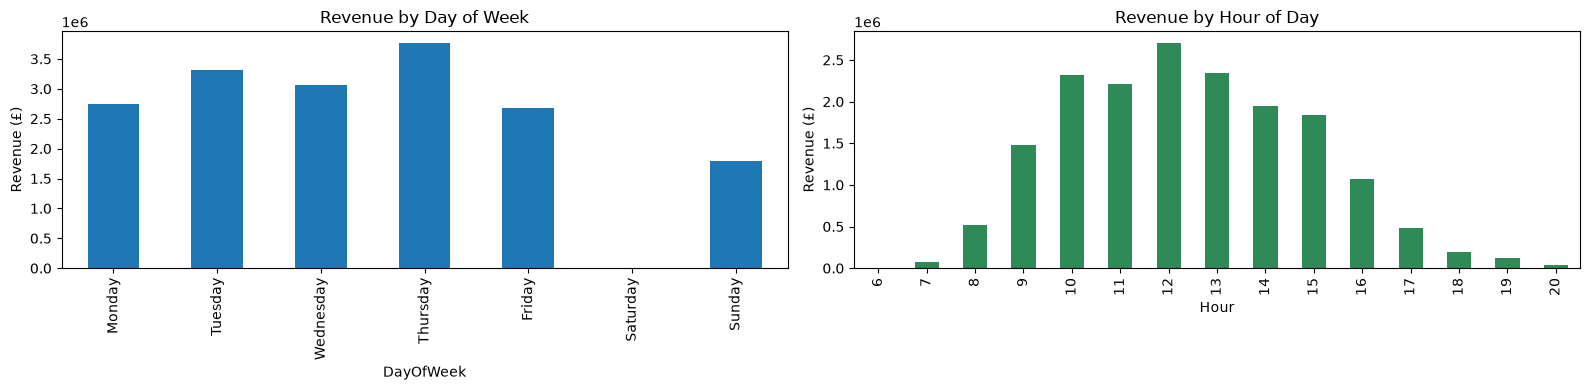

In [27]:
# Day-of-week and hour-of-day patterns
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
 
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order).plot(kind='bar', ax=axes[0])
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£)')
 
df_clean.groupby('Hour')['Revenue'].sum().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


### Top products


=== 4. TOP PRODUCTS ===
Top 10 by quantity sold:
 Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108929
WHITE HANGING HEART T-LIGHT HOLDER     93520
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79694
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75597
BROCADE RING PURSE                     71093
PACK OF 60 PINK PAISLEY CAKE CASES     55101
60 TEATIME FAIRY CAKE CASES            53320
PACK OF 72 RETROSPOT CAKE CASES        46046
Name: Quantity, dtype: int64

Top 10 by revenue:
 Description
REGENCY CAKESTAND 3 TIER              285992.35
WHITE HANGING HEART T-LIGHT HOLDER    251731.26
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               136684.79
ASSORTED COLOUR BIRD ORNAMENT         126704.06
PARTY BUNTING                         103802.53
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79455.68
CHILLI LIGHTS                          72

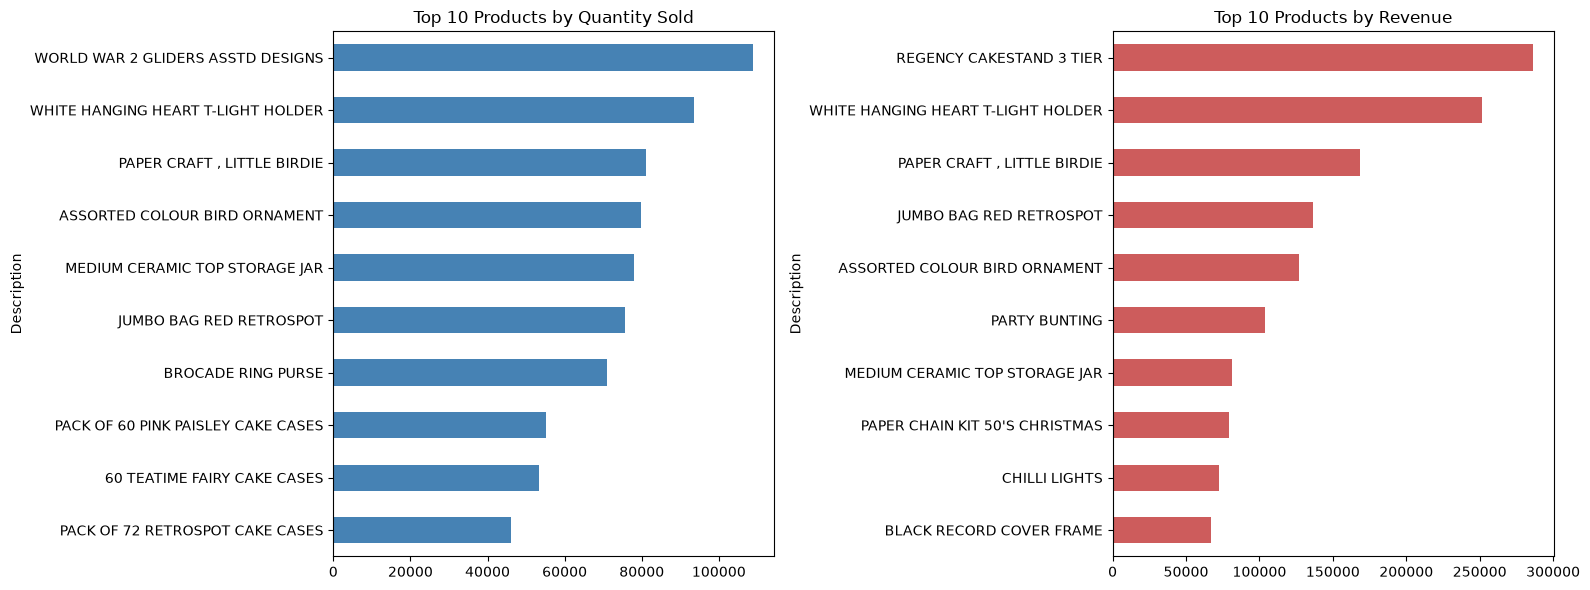

In [28]:
# -----------------------------------------------------------------------
# 4. Top products
# -----------------------------------------------------------------------
print("\n=== 4. TOP PRODUCTS ===")
top_products_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 by quantity sold:\n", top_products_qty)
 
top_products_rev = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 by revenue:\n", top_products_rev)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_products_qty.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity Sold')
 
top_products_rev.sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Products by Revenue')
plt.tight_layout()
plt.show()


### 5. Sales by country


=========================== 5. SALES BY COUNTRY ==============================
Top 10 countries by revenue:
 Country
United Kingdom    1.456597e+07
EIRE              5.912099e+05
Netherlands       5.499510e+05
Germany           3.882711e+05
France            3.150636e+05
Australia         1.684172e+05
Spain             9.856147e+04
Switzerland       9.362434e+04
Sweden            8.604514e+04
Denmark           6.856019e+04
Name: Revenue, dtype: float64


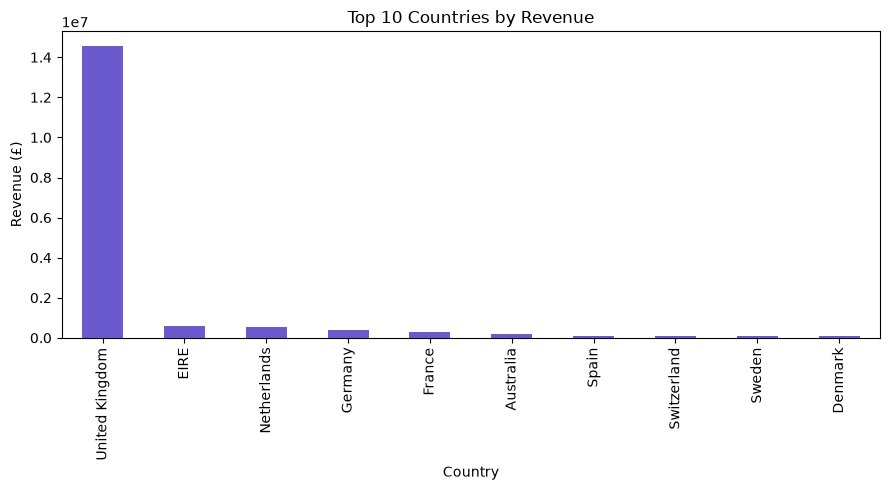

In [29]:
print("\n=========================== 5. SALES BY COUNTRY ==============================")
revenue_by_country = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("Top 10 countries by revenue:\n", revenue_by_country.head(10))
plt.figure(figsize=(9, 5))
revenue_by_country.head(10).plot(kind='bar', color='slateblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


Top 10 countries by order count:
 Country
United Kingdom    33361
Germany             753
France              590
EIRE                528
Netherlands         216
Spain               144
Belgium             143
Sweden               98
Australia            89
Portugal             83
Name: Invoice, dtype: int64

UK share of total revenue: 83.8%


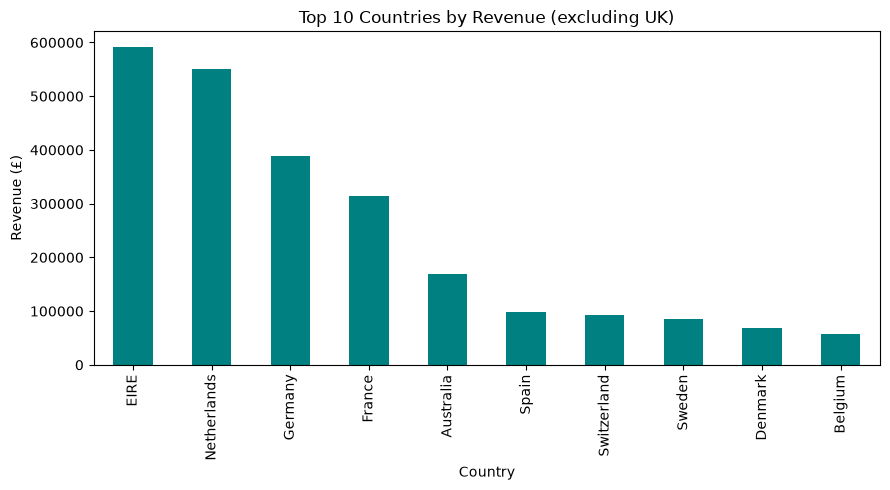

In [30]:
orders_by_country = df_clean.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 10 countries by order count:\n", orders_by_country.head(10))

# UK dominates volume — show UK vs rest of world, and non-UK detail separately
uk_share = revenue_by_country.get('United Kingdom', 0) / revenue_by_country.sum() * 100
print(f"\nUK share of total revenue: {uk_share:.1f}%")
 

plt.figure(figsize=(9, 5))
revenue_by_country.drop('United Kingdom').head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue (excluding UK)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

### 6. Customer-level analysis


======================= 6. CUSTOMER-LEVEL ANALYSIS ================================
Orders per customer:
 count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Invoice, dtype: float64

Top 10 customers by revenue:
 Customer ID
18102    608821.65
14646    526751.52
14156    303392.08
14911    276514.37
17450    246813.09
13694    196482.81
17511    175603.55
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64


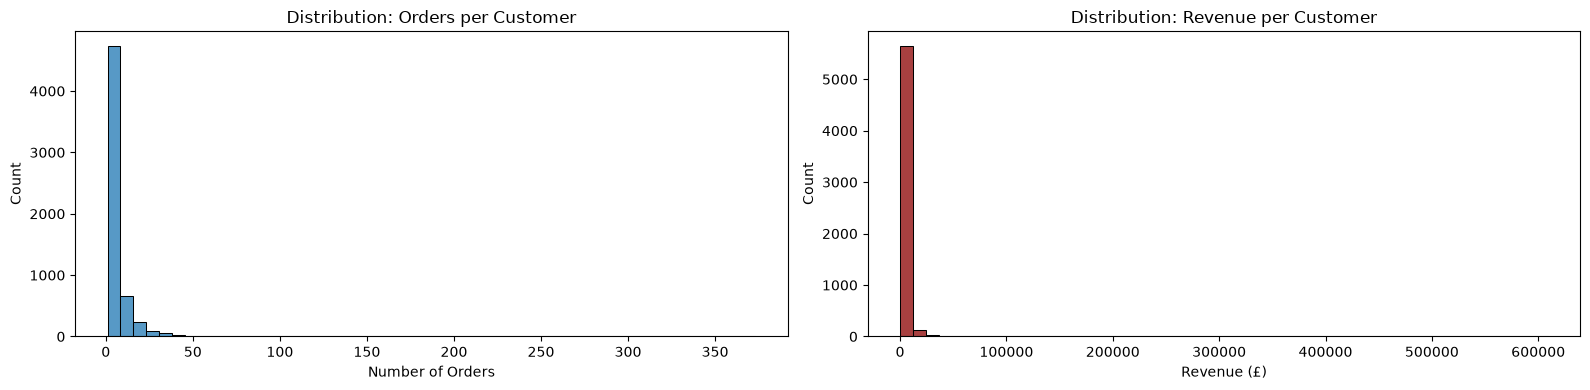


23.0% of customers generate 80% of revenue (1,348 of 5,852 customers)


In [31]:
print("\n======================= 6. CUSTOMER-LEVEL ANALYSIS ================================")
customer_orders = df_clean.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
print("Orders per customer:\n", customer_orders.describe())
 
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
print("\nTop 10 customers by revenue:\n", customer_revenue.head(10))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(customer_orders, bins=50, ax=axes[0])
axes[0].set_title('Distribution: Orders per Customer')
axes[0].set_xlabel('Number of Orders')
 
sns.histplot(customer_revenue, bins=50, ax=axes[1], color='darkred')
axes[1].set_title('Distribution: Revenue per Customer')
axes[1].set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()
 
# Pareto check: what % of customers drive 80% of revenue?
cum_rev_share = (customer_revenue.sort_values(ascending=False).cumsum() / customer_revenue.sum())
n_customers_for_80pct = (cum_rev_share <= 0.80).sum() + 1
pct_customers_for_80pct = n_customers_for_80pct / len(customer_revenue) * 100
print(f"\n{pct_customers_for_80pct:.1f}% of customers generate 80% of revenue "
      f"({n_customers_for_80pct:,} of {len(customer_revenue):,} customers)")


### 7. Basket size


============================== 7. BASKET SIZE (items and value per order) ========================
       ItemsPerBasket  LineItemsPerBasket    BasketValue
count    36594.000000        36594.000000   36594.000000
mean       291.199732           20.935071     474.856120
std       1241.450207           22.404017    1374.086594
min          1.000000            1.000000       0.380000
25%         75.000000            7.000000     160.392500
50%        156.000000           15.000000     304.135000
75%        292.000000           27.000000     483.095000
max      87167.000000          540.000000  168469.600000


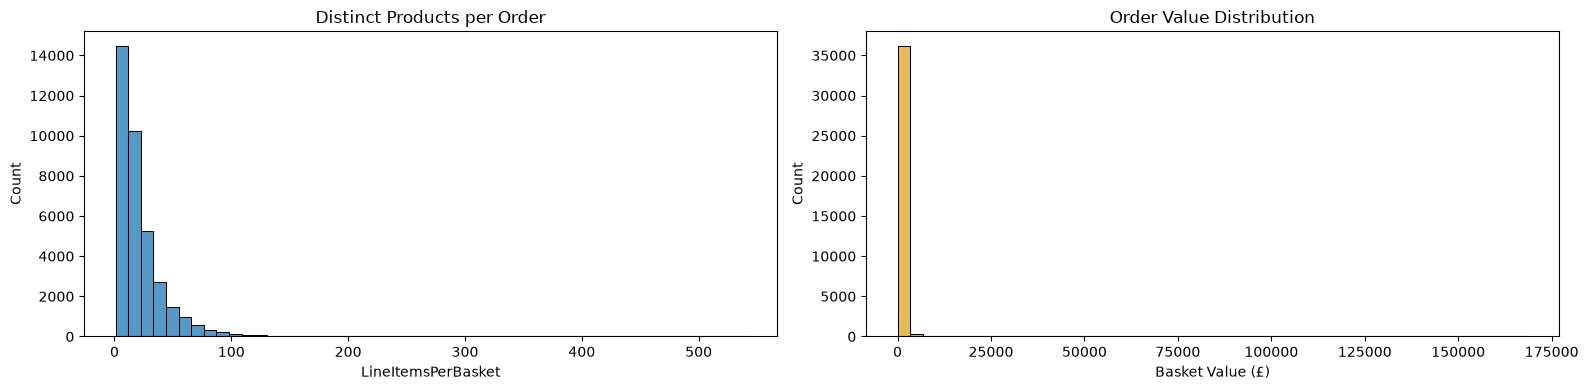

In [32]:
print("\n============================== 7. BASKET SIZE (items and value per order) ========================")
basket = df_clean.groupby('Invoice').agg(
    ItemsPerBasket=('Quantity', 'sum'),
    LineItemsPerBasket=('StockCode', 'nunique'),
    BasketValue=('Revenue', 'sum')
)
print(basket.describe())
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(basket['LineItemsPerBasket'], bins=50, ax=axes[0])
axes[0].set_title('Distinct Products per Order')
 
sns.histplot(basket['BasketValue'], bins=50, ax=axes[1], color='goldenrod')
axes[1].set_title('Order Value Distribution')
axes[1].set_xlabel('Basket Value (£)')
plt.tight_layout()
plt.show()

### 8. Returns exploration (df_returns, set aside during cleaning)

In [33]:
print("\n========================== 8. RETURNS / CANCELLATIONS ==============================")
print(f"Cancelled-order lines: {len(df_returns):,}")
print(f"Cancelled invoices: {df_returns['Invoice'].nunique():,} "
      f"({df_returns['Invoice'].nunique() / df_clean['Invoice'].nunique() * 100:.1f}% of sales invoice count)")
 
returns_by_country = df_returns.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 5 countries by number of cancelled invoices:\n", returns_by_country.head(5))



========================== 8. RETURNS / CANCELLATIONS ==============================
Cancelled-order lines: 17,879
Cancelled invoices: 7,283 (19.9% of sales invoice count)

Top 5 countries by number of cancelled invoices:
 Country
United Kingdom    6492
Germany            282
EIRE               133
France             111
Belgium             29
Name: Invoice, dtype: int64


### 9. Correlation check


========================== 9. CORRELATIONS ===============================
          Quantity     Price   Revenue
Quantity  1.000000 -0.028258  0.833783
Price    -0.028258  1.000000  0.061013
Revenue   0.833783  0.061013  1.000000


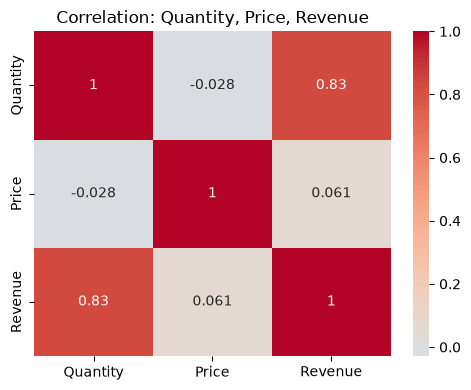

In [34]:
print("\n========================== 9. CORRELATIONS ===============================")
corr = df_clean[['Quantity', 'Price', 'Revenue']].corr()
print(corr)
 
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Quantity, Price, Revenue')
plt.tight_layout()
plt.show()


## To Create Customer Features, customer segmentation, prediction model

PREDICTION MODEL — Customer Churn
Target: will a customer who was active BEFORE the cutoff date make at  least one more purchase in the 6 months AFTER it? 
If not, they're  labeled "churned". 
Features are built only from pre-cutoff data, so the  model never sees the future it's trying to predict (no data leakage).

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')

In [69]:
# -----------------------------------------------------------------------
# 1. RFM feature engineering
# -----------------------------------------------------------------------
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(f"RFM table: {rfm.shape[0]:,} customers")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Quintile scores (1-5), used later to translate clusters into business labels
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

RFM table: 5,852 customers
           Recency    Frequency       Monetary
count  5852.000000  5852.000000    5852.000000
mean    200.198052     6.253247    2969.392491
std     208.509570    12.749286   14599.308267
min       1.000000     1.000000       2.950000
25%      25.000000     1.000000     343.115000
50%      95.000000     3.000000     874.875000
75%     379.000000     7.000000    2281.620000
max     739.000000   373.000000  608821.650000


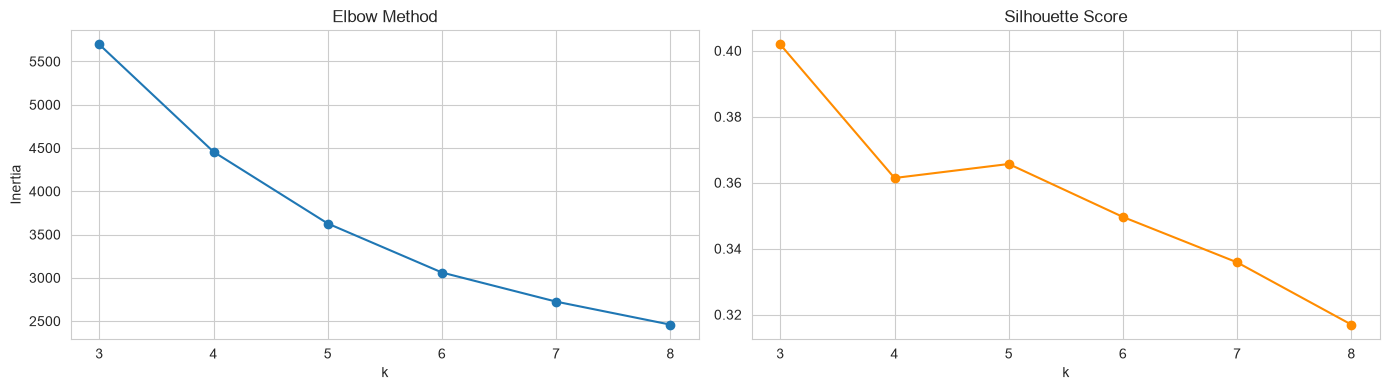

In [70]:
# -----------------------------------------------------------------------
# 2. K-Means clustering
# -----------------------------------------------------------------------
# Frequency and Monetary are heavily right-skewed (a few whale customers),
# so log-transform before scaling — otherwise K-Means' distance metric is
# dominated entirely by the biggest spenders.
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Search k=3..8 and plot both metrics for reference.
k_range = range(3, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

In [71]:
# The CRM brief asks to distinguish groups like VIP, at-risk, and
# one-time buyers — that needs more resolution than the 3-cluster split
# silhouette alone tends to favor here. We pick the best silhouette
# score within k=4..8, trading a little cohesion for buckets the CRM
# team can actually act on differently.
MIN_K_FOR_BUSINESS_USE = 4
candidates = [k for k in k_range if k >= MIN_K_FOR_BUSINESS_USE]
candidate_scores = [silhouettes[list(k_range).index(k)] for k in candidates]
best_k = candidates[int(np.argmax(candidate_scores))]
print(f"\nBest k (k>={MIN_K_FOR_BUSINESS_USE}) by silhouette score: {best_k}  "
      f"(silhouette={max(candidate_scores):.3f})")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)


Best k (k>=4) by silhouette score: 5  (silhouette=0.366)


In [72]:
# 3. Translate clusters into business-facing segment names
# -----------------------------------------------------------------------
# Rule-based label per customer, using the standard RFM scoring logic.
# This vocabulary matches what a CRM team actually asks for.
def business_segment(row):
    r, f, m, freq = row['R_Score'], row['F_Score'], row['M_Score'], row['Frequency']
    if freq == 1:
        return 'One-Time Buyer'
    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    if r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    if r >= 4 and f <= 2:
        return 'New Customer'
    if r <= 2 and f >= 4 and m >= 4:
        return 'Win-Back Priority'   # high past value, gone quiet
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Let Go'
    return 'Needs Attention'


rfm['RuleSegment'] = rfm.apply(business_segment, axis=1)

# Name each K-Means cluster after its most common rule-based segment.
# This grounds the data-driven clusters in the business vocabulary the
# CRM team asked for, instead of arbitrary cluster numbers.
cluster_to_label = (
    rfm.groupby('Cluster')['RuleSegment']
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)
seen = set()
unique_cluster = {}
for k, v in cluster_to_label.items():
    if v not in seen:
        unique_cluster[k] = v
        seen.add(v)
rfm['Segment'] = rfm['Cluster'].map(unique_cluster)

print("\n=== CLUSTER -> BUSINESS SEGMENT MAPPING ===")
print(unique_cluster)
for cluster, label in unique_cluster.items():
    print(f"Cluster {cluster} -> {label}")


=== CLUSTER -> BUSINESS SEGMENT MAPPING ===
{0: 'One-Time Buyer', 1: 'VIP', 3: 'At Risk', 4: 'Loyal Customer'}
Cluster 0 -> One-Time Buyer
Cluster 1 -> VIP
Cluster 3 -> At Risk
Cluster 4 -> Loyal Customer



=== SEGMENT PROFILES ===
                Customers  AvgRecency  AvgFrequency   AvgMonetary  \
Segment                                                             
VIP                   900   42.074444     22.815556  13536.980919   
Loyal Customer       1692   63.794917      5.697991   1940.544590   
At Risk               840  393.536905      3.355952   1290.647894   
One-Time Buyer       1080  520.591667      1.200000    253.937473   

                TotalRevenue  PctCustomers  PctRevenue  
Segment                                                 
VIP             1.218328e+07     15.379357   70.112008  
Loyal Customer  3.283401e+06     28.913192   18.895225  
At Risk         1.084144e+06     14.354067    6.239002  
One-Time Buyer  2.742525e+05     18.455229    1.578260  


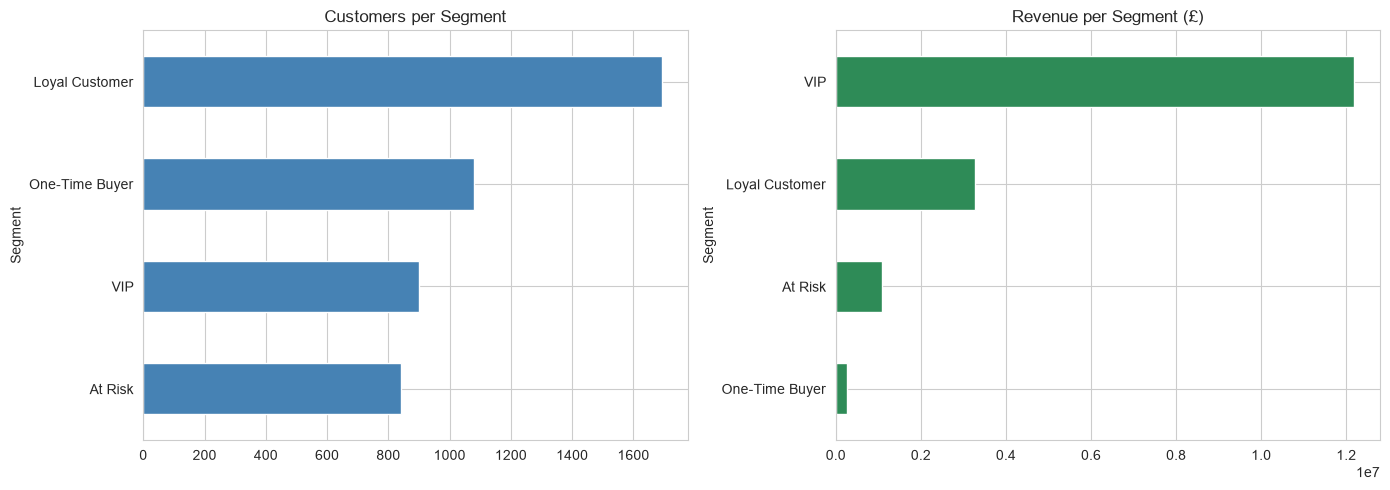

In [73]:
# 4. Segment profiles (what the CRM team will actually read)
# -----------------------------------------------------------------------
print("\n=== SEGMENT PROFILES ===")
profile = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).sort_values('TotalRevenue', ascending=False)
profile['PctCustomers'] = profile['Customers'] / len(rfm) * 100
profile['PctRevenue'] = profile['TotalRevenue'] / rfm['Monetary'].sum() * 100
print(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
profile['Customers'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Customers per Segment')

profile['TotalRevenue'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Revenue per Segment (£)')
plt.tight_layout()
plt.show()


PCA explained variance ratio: [0.74551575 0.20509672] (total: 95.1%)


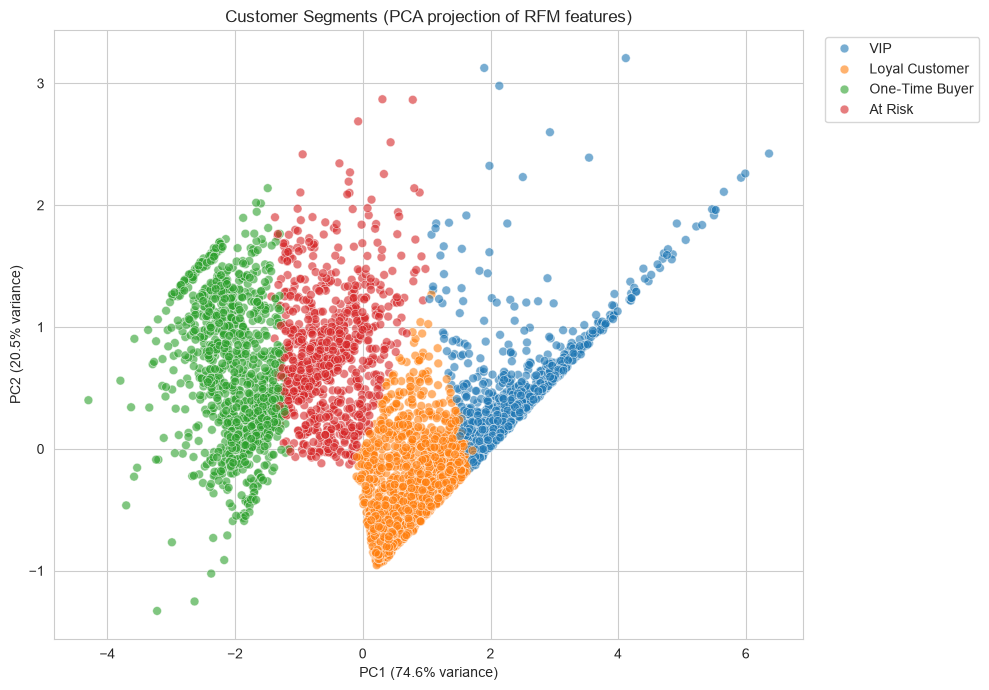

In [74]:
# -----------------------------------------------------------------------
# 5. PCA visualization
# -----------------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_} "
      f"(total: {pca.explained_variance_ratio_.sum():.1%})")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=rfm, x='PCA1', y='PCA2', hue='Segment',
    palette='tab10', alpha=0.6, s=40
)
plt.title('Customer Segments (PCA projection of RFM features)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [75]:
# -----------------------------------------------------------------------
# 6. Business recommendation cheat-sheet
# -----------------------------------------------------------------------
action_map = {
    'VIP': 'Court: white-glove service, early access, loyalty rewards',
    'Loyal Customer': 'Court: upsell/cross-sell, referral incentives',
    'New Customer': 'Court: onboarding series, second-purchase discount',
    'Win-Back Priority': 'Win back: personal outreach, high-value reactivation offer',
    'At Risk': 'Win back: targeted discount, re-engagement email flow',
    'Needs Attention': 'Monitor: moderate-touch nurture campaign',
    'One-Time Buyer': 'Convert: post-purchase follow-up, incentivize 2nd order',
    'Lost / Let Go': 'Let go: exclude from paid marketing spend, low-cost win-back only',
}
profile['RecommendedAction'] = profile.index.map(action_map)
print("\n=== RECOMMENDED CRM ACTION PER SEGMENT ===")
print(profile[['Customers', 'PctRevenue', 'RecommendedAction']])

# rfm now carries Segment, Cluster, PCA1/PCA2 — ready for the prediction
# model step or for exporting a customer-level action list.


=== RECOMMENDED CRM ACTION PER SEGMENT ===
                Customers  PctRevenue  \
Segment                                 
VIP                   900   70.112008   
Loyal Customer       1692   18.895225   
At Risk               840    6.239002   
One-Time Buyer       1080    1.578260   

                                                RecommendedAction  
Segment                                                            
VIP             Court: white-glove service, early access, loya...  
Loyal Customer      Court: upsell/cross-sell, referral incentives  
At Risk         Win back: targeted discount, re-engagement ema...  
One-Time Buyer  Convert: post-purchase follow-up, incentivize ...  
